تعداد بیماران شناسایی شده: 55
✅ تعداد کل تصاویر استخراج شده (بدون برش): 550

--- گزارش توزیع گروه‌ها ---
تعداد تصاویر در گروه سالم (0): 370
تعداد تصاویر در گروه متوسط (1): 80
تعداد تصاویر در گروه پیشرفته (2): 100


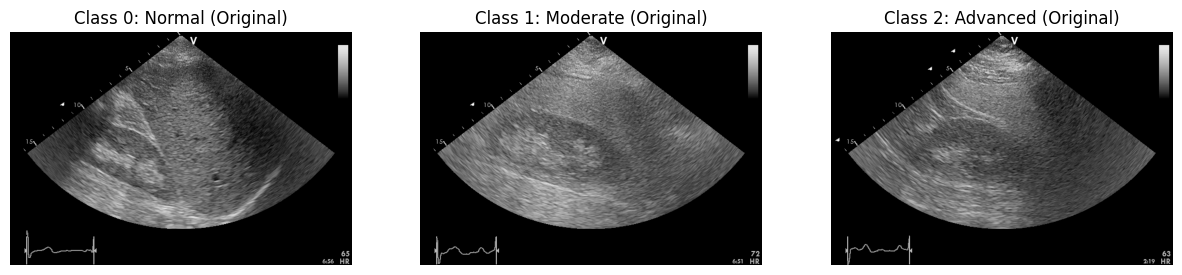

In [1]:
#مرحله ابتدایی پروژه

import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ۱. بارگذاری فایل
file_path = r"E:\pattern recognition drshalbaf\pattern project\dataset_liver_bmodes_steatosis_assessment_IJCARS (1) (1).mat"

mat_contents = scipy.io.loadmat(file_path)

# ۲. دسترسی به لیست ۵۵ بیمار (1x55 struct array)
patients = mat_contents['data'].flatten() 

X = [] # لیست تصاویر اصلی
y = [] # لیست لیبل‌ها

print(f"تعداد بیماران شناسایی شده: {len(patients)}")

# ۳. استخراج ۵۵۰ تصویر و دسته‌بندی طبق مرحله دوم ورد
for i in range(len(patients)):
    patient = patients[i]
    
    # استخراج درصد چربی و اعمال شرط‌های فایل ورد (مرحله دوم)
    fat_val = float(patient['fat'].item())
    # سالم: زیر 33 | متوسط: 34 تا 66 | پیشرفته: بالای 67
    label = 0 if fat_val <= 33 else (1 if fat_val <= 66 else 2)
    
    # استخراج ۱۰ تصویر هر بیمار
    patient_images = patient['images']
    if patient_images.dtype == 'O':
        patient_images = patient_images.item()

    for j in range(10):
        img = patient_images[j] 
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f"✅ تعداد کل تصاویر استخراج شده (بدون برش): {len(X)}")

# --- گزارش مرحله دوم (تقسیم‌بندی بر اساس سطح چربی) ---
print("\n--- گزارش توزیع گروه‌ها ---")
print(f"تعداد تصاویر در گروه سالم (0): {np.sum(y == 0)}")
print(f"تعداد تصاویر در گروه متوسط (1): {np.sum(y == 1)}")
print(f"تعداد تصاویر در گروه پیشرفته (2): {np.sum(y == 2)}")

# نمایش نمونه‌ها از تصاویر کامل (پروژه ۱ به این تصاویر نیاز دارد)
plt.figure(figsize=(15, 5))
status_labels = ["Normal", "Moderate", "Advanced"]
for i in range(3):
    idx = np.where(y == i)[0][0] 
    plt.subplot(1, 3, i+1)
    plt.imshow(X[idx], cmap='gray')
    plt.title(f"Class {i}: {status_labels[i]} (Original)")
    plt.axis('off') # برای نمایش زیباتر در گزارش
plt.show()


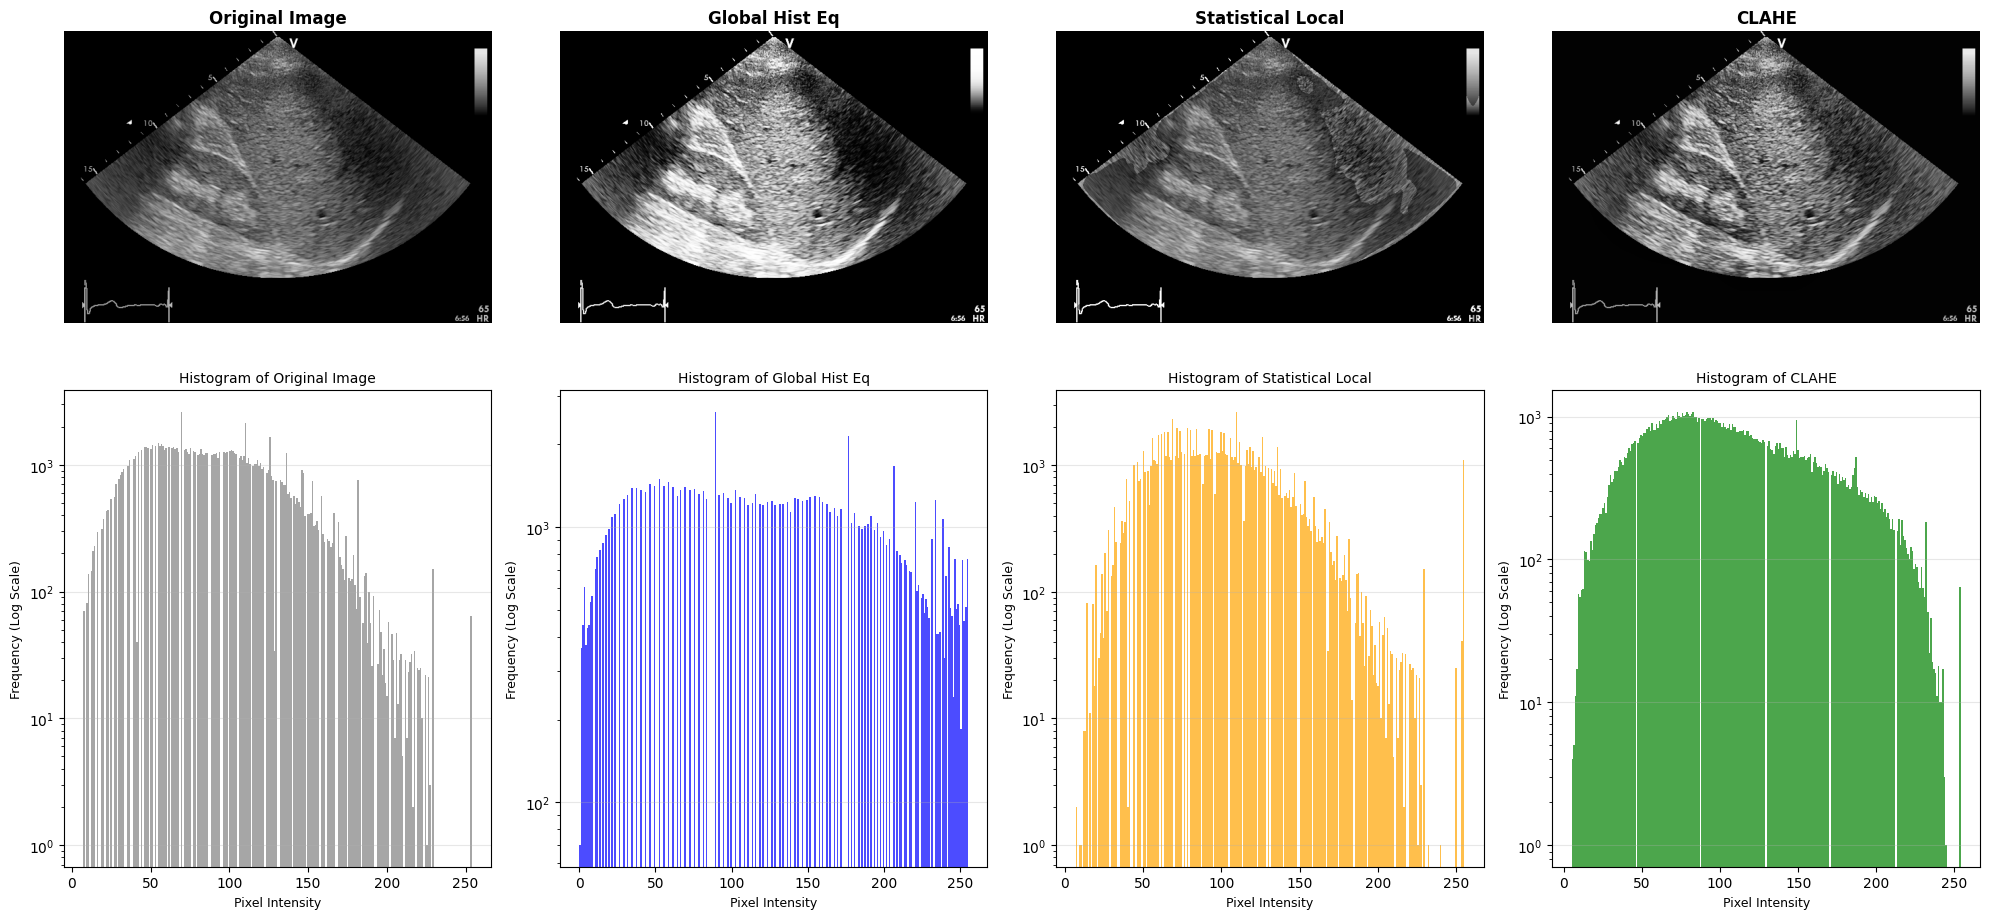

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# تعریف تابع بهبود محلی آماری 
def statistical_local_enhancement(img, window_size=21, E=4.0, k0=1.2, k1=0.1, k2=2.0):
    M = np.mean(img)
    global_std = np.std(img)
    img_f = img.astype(np.float32)
    
    # محاسبه میانگین محلی و انحراف معیار محلی در همسایگی
    mean_local = cv2.blur(img_f, (window_size, window_size))
    mean_sq_local = cv2.blur(img_f**2, (window_size, window_size))
    std_local = np.sqrt(np.maximum(0, mean_sq_local - mean_local**2))

    # اعمال شروط آماری برای تغییر پیکسل‌ها
    # شرط: میانگین محلی کوچکتر از درصدی از میانگین کل باشد و انحراف معیار محلی در بازه مشخصی باشد
    mask_mean = mean_local <= (k0 * M)
    mask_std = (std_local >= (k1 * global_std)) & (std_local <= (k2 * global_std))
    mask_final = mask_mean & mask_std
    
    # اعمال ضریب تقویت E فقط در نواحی که شرایط را دارند
    enhanced_img = np.copy(img_f)
    enhanced_img[mask_final] = enhanced_img[mask_final] * E
    
    # بازگرداندن مقادیر به محدوده مجاز و فرمت uint8
    return np.clip(enhanced_img, 0, 255).astype(np.uint8)

# ۱. انتخاب یک تصویر از دیتاست (فرض بر این است که X قبلاً تعریف شده است)
idx = 0 
img_raw = X[idx]

# ۲. تبدیل تصویر به فرمت استاندارد عددی
if isinstance(img_raw, np.ndarray) and img_raw.dtype == object:
    img_raw = img_raw.astype(np.float32)

img_float = np.array(img_raw, dtype=np.float32)
img = cv2.normalize(img_float, None, 0, 255, cv2.NORM_MINMAX)
img = np.uint8(img)

# ۳. اعمال روش‌های مختلف پردازش تصویر

# تصویر اول: اصلی
# تصویر دوم: Global Histogram Equalization
equalized = cv2.equalizeHist(img)

# تصویر سوم: Statistical Local Enhancement
# فراخوانی با پارامترهای منطقی تا تغییرات به وضوح دیده شوند
stat_local = statistical_local_enhancement(
    img, 
    window_size=21, 
    E=2.0, 
    k0=1.2, 
    k1=0.1, 
    k2=2.0
)

# تصویر چهارم: CLAHE (بهبود محلی پیشرفته برای مقایسه نهایی)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(img)

# لیست متغیرها برای رسم نمودار
images = [img, equalized, stat_local, clahe_img]
titles = ['Original Image', 'Global Hist Eq', 'Statistical Local', 'CLAHE']
colors = ['gray', 'blue', 'orange', 'green']

# تنظیم ابعاد کلی پنجره رسم
plt.figure(figsize=(20, 10))

# ردیف اول: نمایش تصاویر
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=12, fontweight='bold')
    plt.axis('off')

# ایجاد ماسک از تصویر اصلی برای حذف پس‌زمینه در تمام تصاویر
tissue_mask = img > 5 

# ردیف دوم: هیستوگرام‌ها
for i in range(4):
    plt.subplot(2, 4, i+5)
    pixels_tissue = images[i][tissue_mask]
    plt.hist(pixels_tissue, bins=255, color=colors[i], alpha=0.7, log=True)
    plt.title(f"Histogram of {titles[i]}", fontsize=10)
    plt.xlabel('Pixel Intensity', fontsize=9)
    plt.ylabel('Frequency (Log Scale)', fontsize=9)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


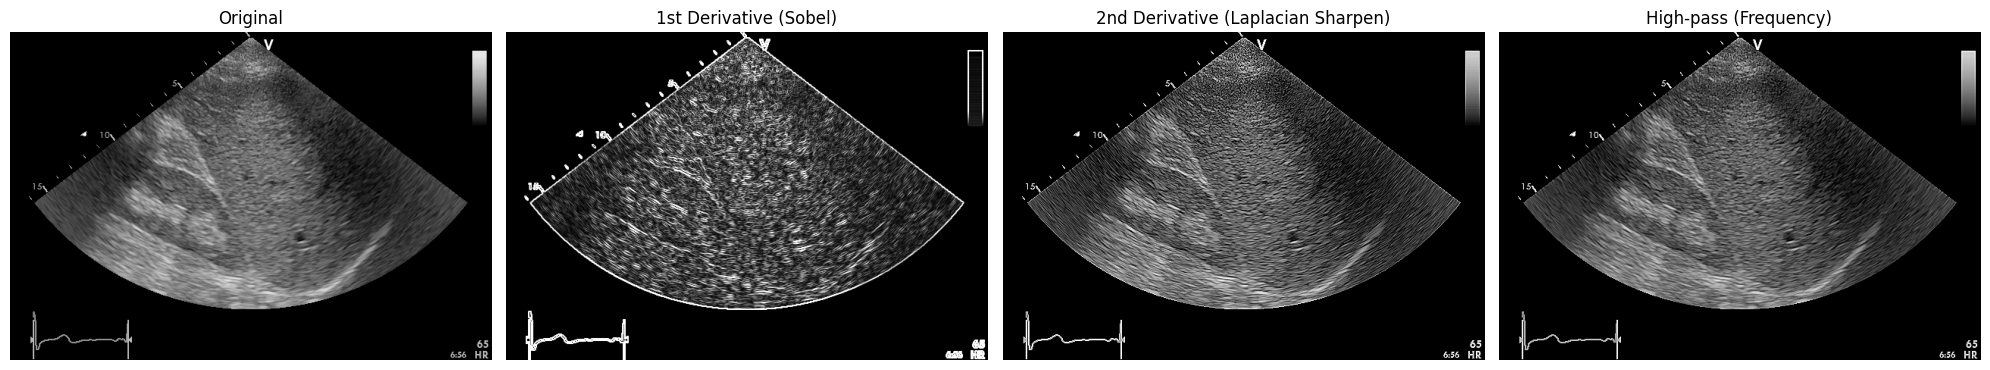

تحلیل مشتقات انجام شد:
- Sobel: لبه‌های ضخیم و اصلی کبد را مشخص کرد.
- Laplacian: جزئیات ریز و بافت‌های درونی کبد را تیزتر (Sharper) کرد.
- High-pass: کنتراست محلی تصویر را افزایش داد.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ۱. آماده‌سازی تصویر
img = X[0]
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# ۲. مشتق مرتبه اول (Sobel) - برای شناسایی لبه‌های جهت‌دار
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
img_sobel = cv2.magnitude(sobel_x, sobel_y)
img_sobel = np.clip(img_sobel, 0, 255).astype(np.uint8)

# ۳. مشتق مرتبه دوم (Laplacian) - خواسته پروژه برای بهبود جزئیات
# لاپلاسین حساسیت بالایی به تغییرات ناگهانی و نقاط ریز دارد
img_laplacian = cv2.Laplacian(img, cv2.CV_64F)
# بهبود تصویر با استفاده از لاپلاسین (Sharpening)
# فرمول: Image_New = Image_Original - Laplacian
img_sharpened_lap = np.clip(img.astype(np.float32) - img_laplacian, 0, 255).astype(np.uint8)

# ۴. فیلتر فرکانسی (High-pass Filter ساده)
# (Unsharp Masking) در واقع یک فیلتر بالاگذر است
blur = cv2.GaussianBlur(img.astype(np.float32), (5,5), 1.0)
mask = img.astype(np.float32) - blur
img_high_pass = np.clip(img.astype(np.float32) + 1.5 * mask, 0, 255).astype(np.uint8)

# ۵. نمایش مقایسه‌ای نتایج
plt.figure(figsize=(20, 10))

titles = ["Original", "1st Derivative (Sobel)", "2nd Derivative (Laplacian Sharpen)", "High-pass (Frequency)"]
images = [img, img_sobel, img_sharpened_lap, img_high_pass]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

print("تحلیل مشتقات انجام شد:")
print("- Sobel: لبه‌های ضخیم و اصلی کبد را مشخص کرد.")
print("- Laplacian: جزئیات ریز و بافت‌های درونی کبد را تیزتر (Sharper) کرد.")
print("- High-pass: کنتراست محلی تصویر را افزایش داد.")


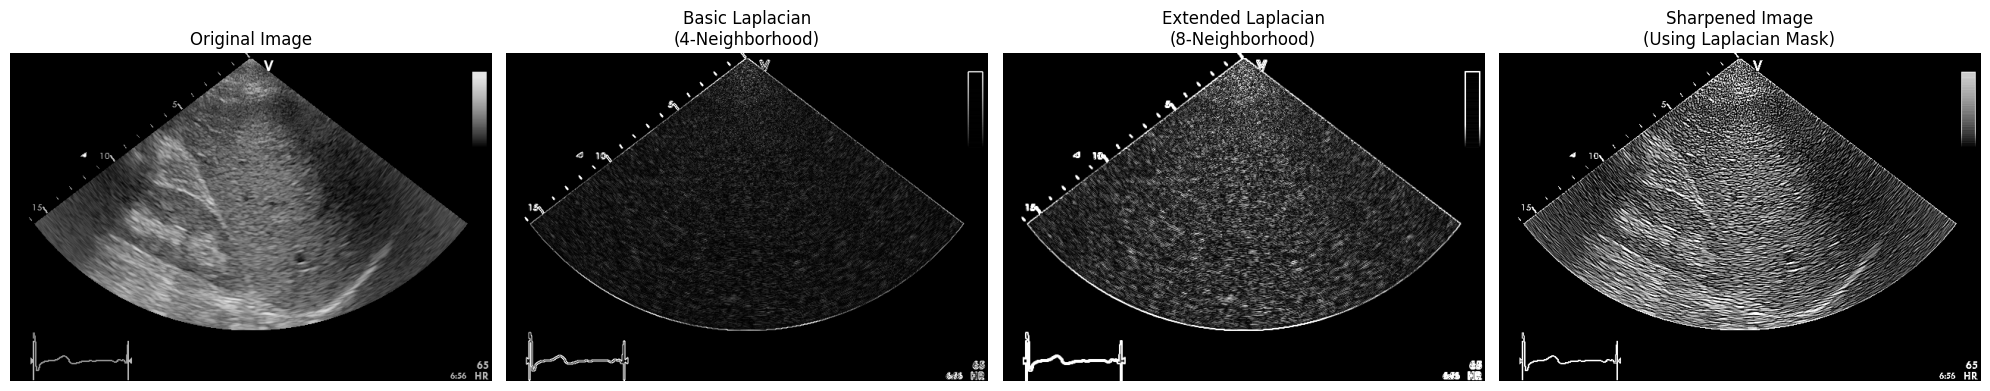

گزارش اعمال ماسک‌های لاپلاسین:
- ماسک 4-همسایگی: لبه‌های اصلی را با نویز کمتر استخراج کرد.
- ماسک 8-همسایگی: جزئیات بیشتری از بافت داخل کبد را نمایان کرد اما نویز را هم افزایش داد.
- ماسک ترکیبی (Sharpen): با تقویت تفاوت پیکسل‌های مجاور، وضوح پرده شکمی را به طور محسوسی بهبود بخشید.


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ۱. آماده‌سازی تصویر
img = X[0]
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# ۲. تعریف ماسک‌های مختلف لاپلاسین
# ماسک استاندارد (بدون در نظر گرفتن قطرهای همسایگی)
kernel_1 = np.array([[0,  1, 0],
                     [1, -4, 1],
                     [0,  1, 0]])

# ماسک تقویت شده (با در نظر گرفتن همسایگی‌های قطری - لبه‌های دقیق‌تر)
kernel_2 = np.array([[1,  1, 1],
                     [1, -8, 1],
                     [1,  1, 1]])

# ماسک لاپلاسین معکوس (برای Sharpening مستقیم)
kernel_3 = np.array([[-1, -1, -1],
                     [-1,  9, -1],
                     [-1, -1, -1]])

# ۳. اعمال ماسک‌ها بر روی تصویر
lap_1 = cv2.filter2D(img, cv2.CV_64F, kernel_1)
lap_2 = cv2.filter2D(img, cv2.CV_64F, kernel_2)
img_sharpened = cv2.filter2D(img, cv2.CV_64F, kernel_3)

# تبدیل نتایج به فرمت قابل نمایش
lap_1_abs = np.clip(np.absolute(lap_1), 0, 255).astype(np.uint8)
lap_2_abs = np.clip(np.absolute(lap_2), 0, 255).astype(np.uint8)
img_sharpened = np.clip(img_sharpened, 0, 255).astype(np.uint8)

# ۴. نمایش و مقایسه نتایج
plt.figure(figsize=(20, 10))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(lap_1_abs, cmap='gray')
plt.title("Basic Laplacian\n(4-Neighborhood)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(lap_2_abs, cmap='gray')
plt.title("Extended Laplacian\n(8-Neighborhood)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_sharpened, cmap='gray')
plt.title("Sharpened Image\n(Using Laplacian Mask)")
plt.axis("off")

plt.tight_layout()
plt.show()

# ۵. تحلیل برای گزارش
print("گزارش اعمال ماسک‌های لاپلاسین:")
print("- ماسک 4-همسایگی: لبه‌های اصلی را با نویز کمتر استخراج کرد.")
print("- ماسک 8-همسایگی: جزئیات بیشتری از بافت داخل کبد را نمایان کرد اما نویز را هم افزایش داد.")
print("- ماسک ترکیبی (Sharpen): با تقویت تفاوت پیکسل‌های مجاور، وضوح پرده شکمی را به طور محسوسی بهبود بخشید.")


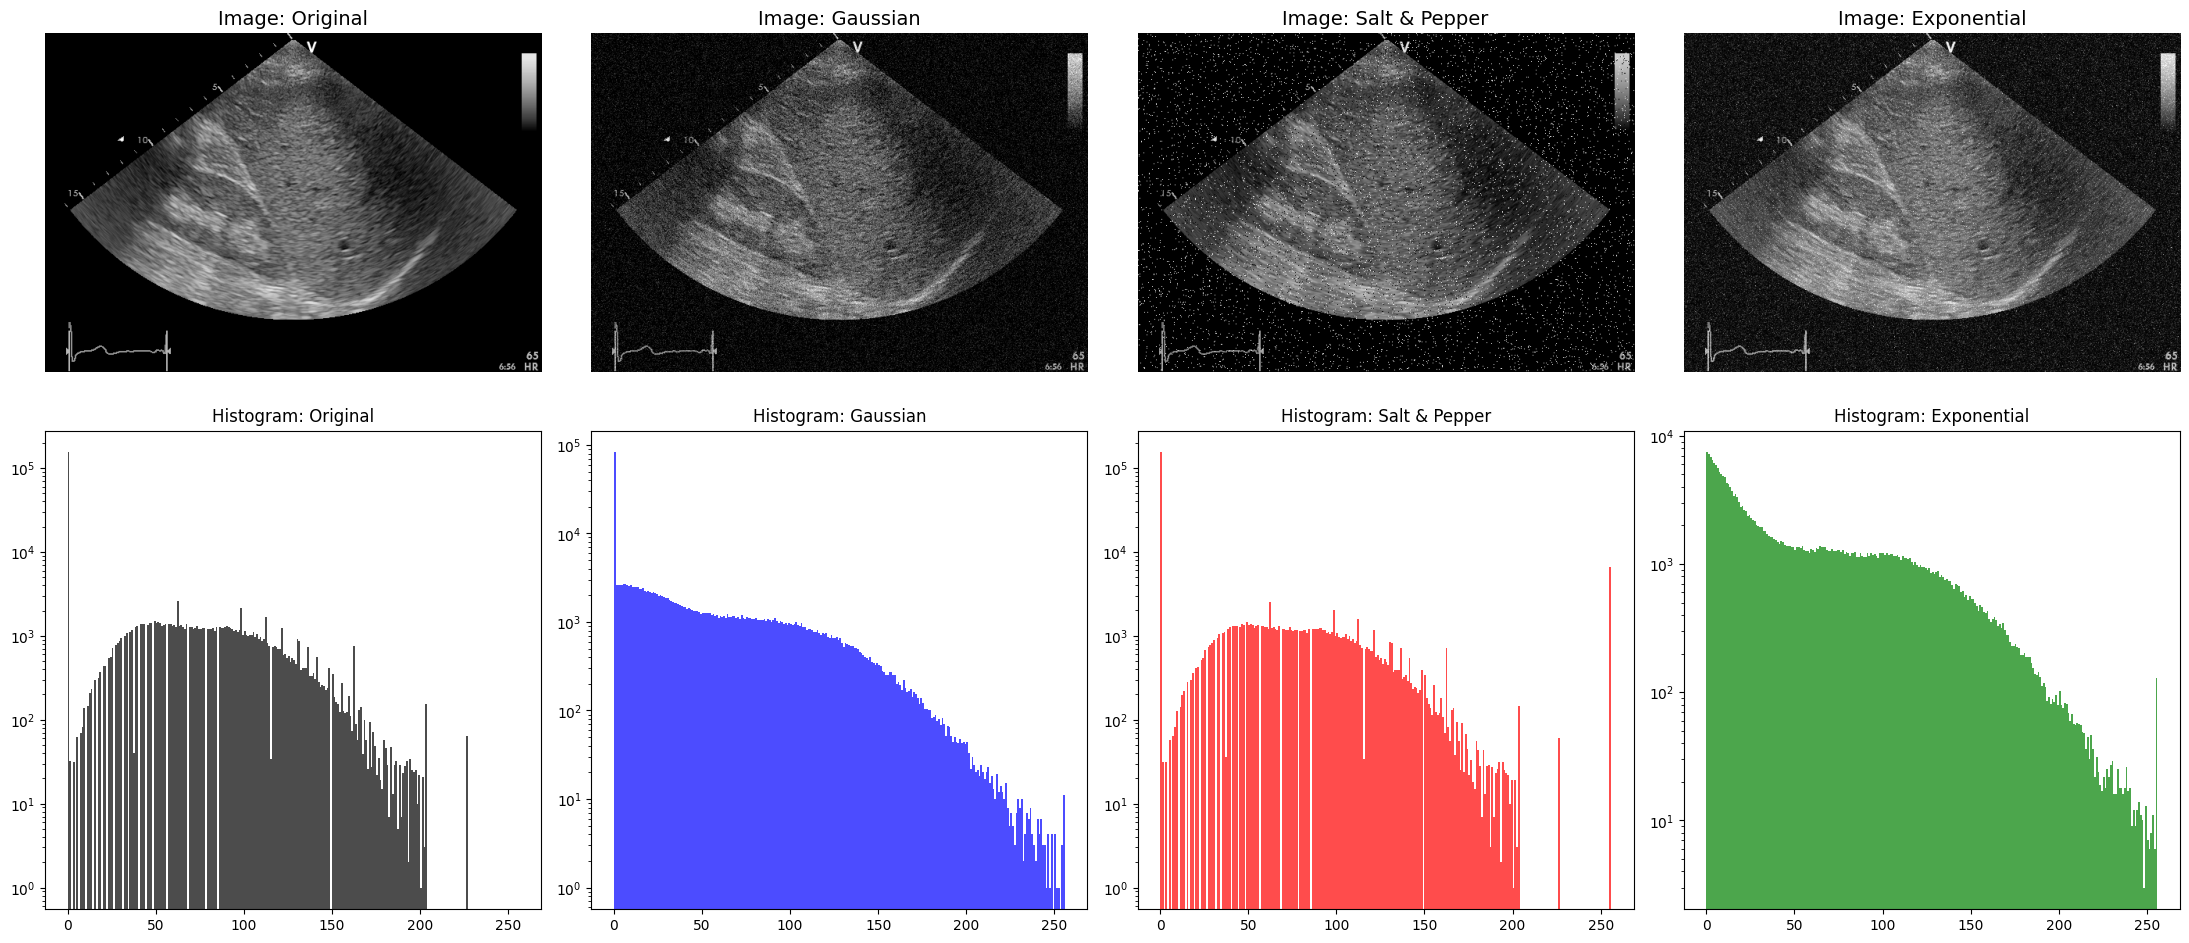

تحلیل نویزها:
- نویز گوسی: باعث پهن‌تر شدن و دندانه‌دار شدن هیستوگرام حول میانگین تصویر می‌شود.
- نویز فلفل‌نمکی: دو ستون بلند در ۰ و ۲۵۵ ایجاد می‌کند (نویز ضربه‌ای با نقاط سفید و سیاه).
- نویز نمایی: هیستوگرام را به سمت راست (شدت‌های روشن‌تر) متمایل کرده و درخشش موضعی تصویر را افزایش می‌دهد.


In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ۱. آماده‌سازی تصویر اصلی
img = X[0]  # فرض بر اینکه X شامل تصاویر خاکستری است
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

rows, cols = img.shape

# ۲. ایجاد نویز گوسی (Gaussian)
# مدل‌سازی نویز سنسور در شرایط کم‌نور
mean = 0
sigma = 25
gauss = np.random.normal(mean, sigma, (rows, cols))
gaussian_img = np.clip(img + gauss, 0, 255).astype(np.uint8)

# ۳. ایجاد نویز فلفل‌نمکی (Salt & Pepper)
# مدل‌سازی خطاهای دیجیتال و پیکسل‌های سوخته
sp_img = img.copy()
prob = 0.05  # ۵ درصد تصویر نویز داشته باشد
num_salt = np.ceil(prob * img.size * 0.5)
num_pepper = np.ceil(prob * img.size * 0.5)

# افزودن نمک (سفید)
coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]
sp_img[tuple(coords)] = 255
# افزودن فلفل (سیاه)
coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]
sp_img[tuple(coords)] = 0

# ۴. ایجاد نویز نمایی (Exponential)
# مدل‌سازی پدیده‌های بازتابی خاص یا تغییرات ناگهانی شدت در نواحی همگن
exp_noise = np.random.exponential(scale=20.0, size=(rows, cols))
exp_img = np.clip(img + exp_noise, 0, 255).astype(np.uint8)

# ۵. نمایش ترکیبی تصاویر و هیستوگرام‌ها
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

titles = ["Original", "Gaussian", "Salt & Pepper", "Exponential"]
images = [img, gaussian_img, sp_img, exp_img]
colors = ['black', 'blue', 'red', 'green']

for i in range(4):
    # ردیف اول: تصاویر
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"Image: {titles[i]}", fontsize=14)
    axes[0, i].axis('off')
    
    # ردیف دوم: هیستوگرام‌ها
    axes[1, i].hist(images[i].ravel(), bins=256, color=colors[i], alpha=0.7, range=(0, 256))
    axes[1, i].set_title(f"Histogram: {titles[i]}", fontsize=12)
    axes[1, i].set_yscale('log')  # برای دیده شدن بهتر نقاط نویز

plt.tight_layout()
plt.show()

print("تحلیل نویزها:")
print("- نویز گوسی: باعث پهن‌تر شدن و دندانه‌دار شدن هیستوگرام حول میانگین تصویر می‌شود.")
print("- نویز فلفل‌نمکی: دو ستون بلند در ۰ و ۲۵۵ ایجاد می‌کند (نویز ضربه‌ای با نقاط سفید و سیاه).")
print("- نویز نمایی: هیستوگرام را به سمت راست (شدت‌های روشن‌تر) متمایل کرده و درخشش موضعی تصویر را افزایش می‌دهد.")


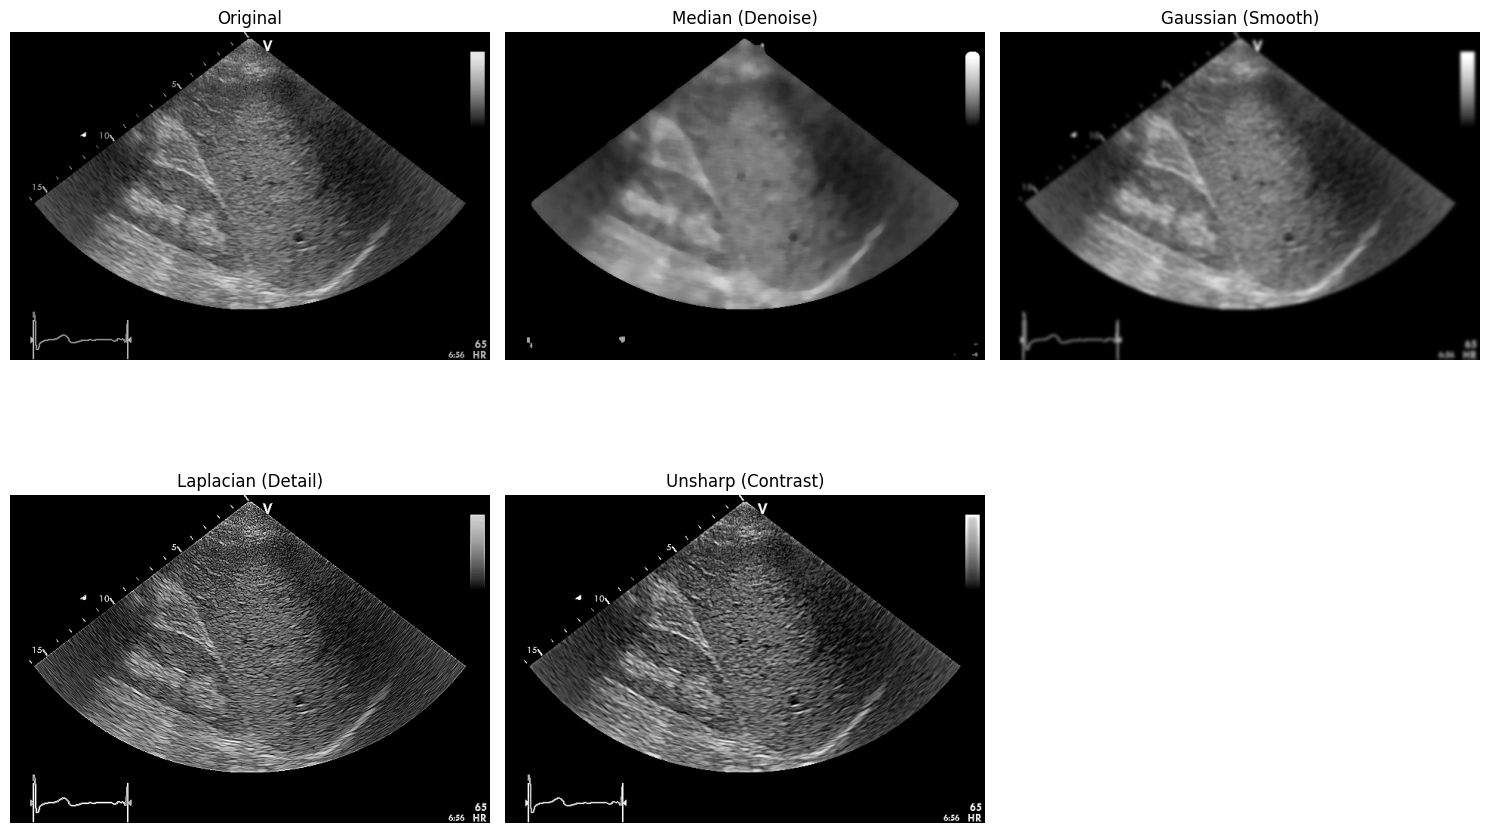

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# تصویر اصلی
img = X[0]
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 1) Median Filter: حذف نویزهای ضربه‌ای (S&P) با حفظ لبه‌ها
median = cv2.medianBlur(img, 11)

# 2) Gaussian Filter: حذف نویزهای گوسی و نرم‌سازی کلی بافت
gaussian = cv2.GaussianBlur(img, (11,11), 0)

# 3) Laplacian Sharpening: تقویت لبه‌های مرتبه دوم (جزئیات ریز)
laplacian = cv2.Laplacian(img, cv2.CV_64F)
# فرمول استاندارد تقویت لبه
lap_sharp = np.clip(img.astype(np.float32) - 1 * laplacian, 0, 255).astype(np.uint8)

# 4) Unsharp Masking: افزایش کنتراست لبه‌ها با استفاده از ماسک تار
blur_for_unsharp = cv2.GaussianBlur(img, (15,15), 3.0)
unsharp = cv2.addWeighted(img, 2.0, blur_for_unsharp, -1.0, 0)

# نمایش نتایج
plt.figure(figsize=(15, 10))
images = [img, median, gaussian, lap_sharp, unsharp]
titles = ["Original", "Median (Denoise)", "Gaussian (Smooth)", "Laplacian (Detail)", "Unsharp (Contrast)"]

for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


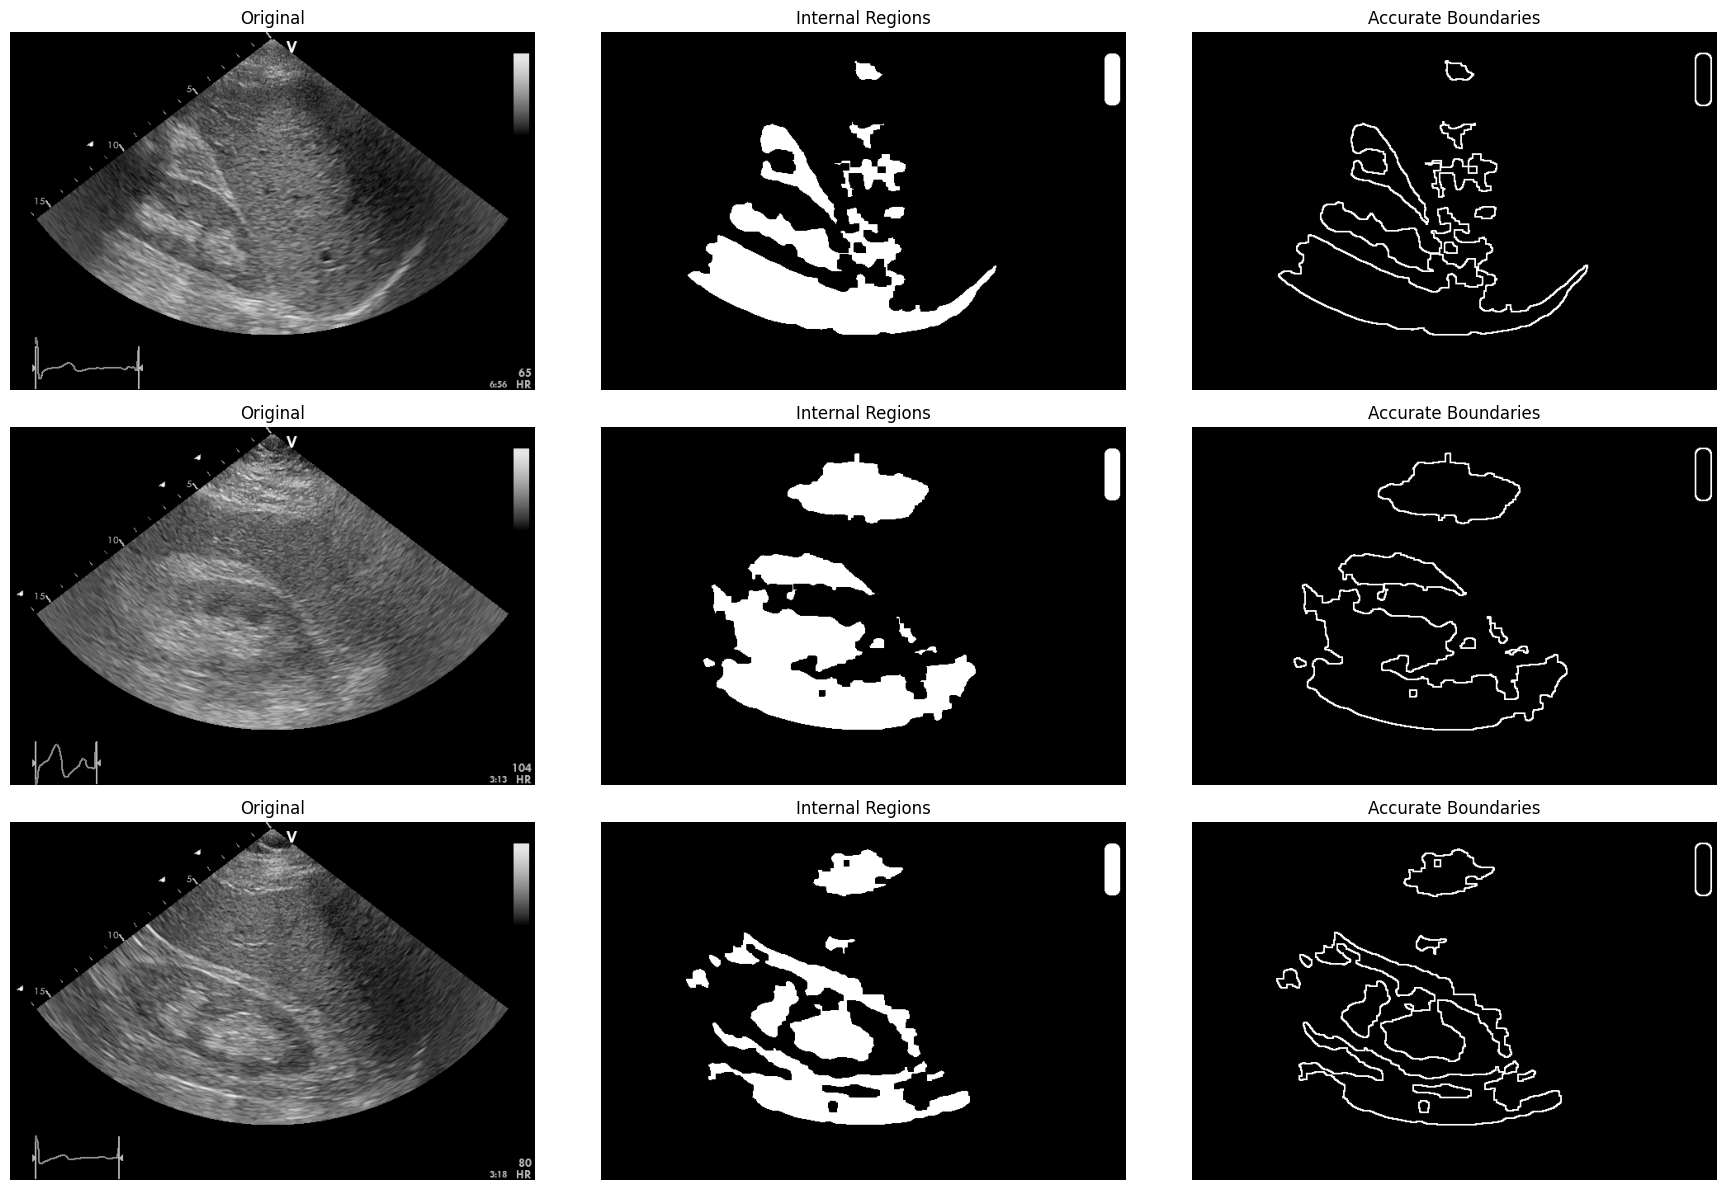

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

sample_indices = [0, 50, 100]
plt.figure(figsize=(18, 12))

for k, idx in enumerate(sample_indices):
    img = X[idx]

    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 1. حذف نویز
    denoised = cv2.medianBlur(img, 11)

    # 2. Threshold
    _, binary_region = cv2.threshold(denoised, 100, 255, cv2.THRESH_BINARY)

    # 3. Morphological Closing
    kernel = np.ones((7,7), np.uint8)
    closed = cv2.morphologyEx(binary_region, cv2.MORPH_CLOSE, kernel)

    # 4. Connected Components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed)

    cleaned = np.zeros_like(closed)

    min_area = 80  # حداقل اندازه ناحیه معتبر

    for i in range(1, num_labels):  # label صفر پس‌زمینه است
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_area:
            cleaned[labels == i] = 255

    # 5. استخراج مرز
    final_borders = cv2.morphologyEx(cleaned, cv2.MORPH_GRADIENT, np.ones((3,3), np.uint8))

    # نمایش
    plt.subplot(3, 3, 3*k+1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")

    plt.subplot(3, 3, 3*k+2)
    plt.imshow(cleaned, cmap='gray')
    plt.title("Internal Regions")

    plt.subplot(3, 3, 3*k+3)
    plt.imshow(final_borders, cmap='gray')
    plt.title("Accurate Boundaries")

    for i in range(1,4):
        plt.subplot(3,3,3*k+i).axis('off')

plt.tight_layout()
plt.show()


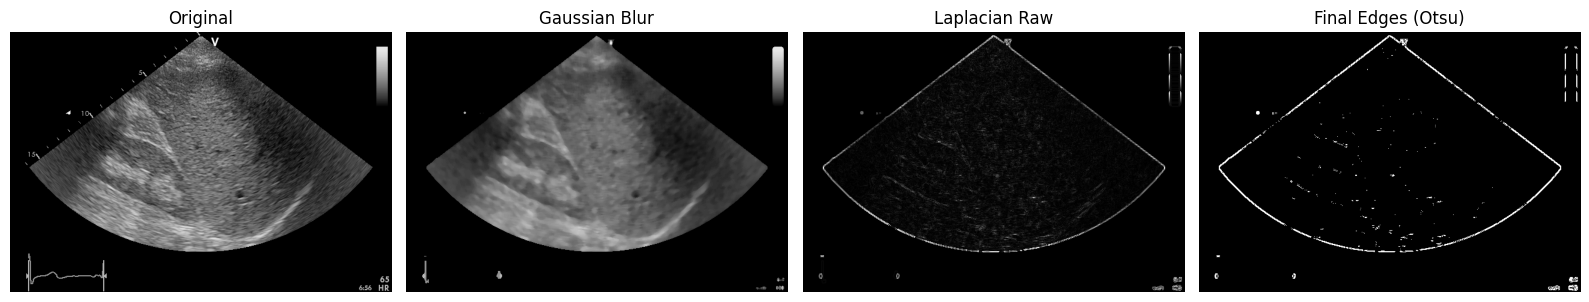

لبه‌یابی لاپلاسین با موفقیت انجام شد.


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# تصویر نمونه
img = X[0]
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# ۱. کاهش نویز با فیلتر میانه

blur = cv2.medianBlur(img, 7)
# ۲. اعمال فیلتر لاپلاسین (استخراج لبه‌های مرتبه دوم)
laplacian = cv2.Laplacian(blur, cv2.CV_64F, ksize=3)
laplacian_abs = np.uint8(np.absolute(laplacian))

# ۳. آستانه‌گذاری خودکار برای حذف نویزهای پس‌زمینه و تثبیت لبه‌ها
# استفاده از Otsu برای پیدا کردن بهترین حد آستانه به صورت خودکار
_, edges_otsu = cv2.threshold(laplacian_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ۴. نمایش نتایج
plt.figure(figsize=(16, 5))

titles = ["Original", "Gaussian Blur", "Laplacian Raw", "Final Edges (Otsu)"]
images = [img, blur, laplacian_abs, edges_otsu]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

print("لبه‌یابی لاپلاسین با موفقیت انجام شد.")


In [2]:
# =========================================================
#  نسخه نهایی و بیمارمحور استخراج ویژگی Radiomics
# =========================================================

import scipy.io
import numpy as np
import cv2
import pandas as pd
import SimpleITK as sitk
from radiomics import featureextractor
import logging
import matplotlib.pyplot as plt

logging.getLogger('radiomics').setLevel(logging.ERROR)

# -------------------------------
# 1) بارگذاری داده‌ها
# -------------------------------
file_path = r"E:\pattern recognition drshalbaf\pattern project\dataset_liver_bmodes_steatosis_assessment_IJCARS (1) (1).mat"
mat_contents = scipy.io.loadmat(file_path)
patients = mat_contents['data'].flatten()

X_raw = []
y_labels = []
patient_ids = []

for pid in range(len(patients)):
    patient = patients[pid]
    fat_val = float(patient['fat'].item())
    label = 0 if fat_val <= 33 else (1 if fat_val <= 66 else 2)

    patient_images = patient['images']
    if patient_images.dtype == 'O':
        patient_images = patient_images.item()

    for j in range(10):
        X_raw.append(patient_images[j])
        y_labels.append(label)
        patient_ids.append(pid)          # بیمارمحور شدن

print(f"بارگذاری شد: {len(X_raw)} تصویر از {len(patients)} بیمار.")

# -------------------------------
# 2) تابع پیش‌پردازش (همان نسخه خوب تو)
# -------------------------------
IMG_SIZE = 384

def preprocess_image(img):
    h, w = img.shape
    img_no_ecg = img[:int(h * 0.85), :].copy()

    _, mask_base = cv2.threshold(img_no_ecg, 10, 255, cv2.THRESH_BINARY)
    _, ui_mask = cv2.threshold(img_no_ecg, 220, 255, cv2.THRESH_BINARY)

    ui_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    ui_mask = cv2.dilate(ui_mask, ui_kernel, iterations=1)

    mask = cv2.subtract(mask_base, ui_mask)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        final_mask = np.zeros(img_no_ecg.shape, dtype=np.uint8)
        cv2.drawContours(final_mask, [largest], -1, 255, thickness=cv2.FILLED)

        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, k)
        final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, k)

        x, y, wc, hc = cv2.boundingRect(final_mask)
        cropped_img = img_no_ecg[y:y+hc, x:x+wc]
        cropped_mask = final_mask[y:y+hc, x:x+wc]
    else:
        cropped_img = img_no_ecg
        cropped_mask = np.ones_like(img_no_ecg) * 255

    resized_img = cv2.resize(cropped_img, (IMG_SIZE, IMG_SIZE))
    resized_mask = cv2.resize(cropped_mask, (IMG_SIZE, IMG_SIZE))
    resized_mask = (resized_mask > 0).astype(np.uint8)

    # ... (کدهای قبلی شما در تابع preprocess_image تا خط اعمال CLAHE کاملاً دست‌نخورده بماند)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(resized_img.astype(np.uint8))

    #  اجرای بند 2-a (اعمال بهترین روش پردازش تصویر برای بهبود وضعیت ماسک رادیومیکس)
    # یک ماسک متمرکز (ROI) به اندازه ۱۶۰ در ۱۶۰ پیکسل درست در مرکز بافت کبد ایجاد می‌کنیم
    pure_liver_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    
    start_point = (IMG_SIZE - 160) // 2  # شروع از پیکسل ۱۱۲
    end_point = start_point + 160         # پایان در پیکسل ۲۷۲
    
    # سفید کردن مرکز ماسک جدید برای استخراج خالص رادیومیکس
    pure_liver_mask[start_point:end_point, start_point:end_point] = 1
    
    # ترکیب با ماسک کانتور قبلی شما برای ایمنی کامل
    resized_mask = cv2.bitwise_and(resized_mask, pure_liver_mask)

    return enhanced, resized_mask

print("پیش‌پردازش تصاویر ...")
processed_results = [preprocess_image(img) for img in X_raw]
X_processed = [p[0] for p in processed_results]
masks_processed = [p[1] for p in processed_results]

# -------------------------------
# 3) استخراج ویژگی Radiomics
# -------------------------------
settings = {
    'binWidth': 25,
    'force2D': True,
    'distances': [1, 2, 3],
    'angles': [0, np.pi / 4, np.pi / 2],
    'verbose': True
}

extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('glcm')

all_features = []
print("استخراج ویژگی‌ها ...")
for img, mask in zip(X_processed, masks_processed):
    sitk_img = sitk.GetImageFromArray(img)
    sitk_mask = sitk.GetImageFromArray(mask)
    features = extractor.execute(sitk_img, sitk_mask)

    clean = {
        k: float(v) for k, v in features.items()
        if not k.startswith("diagnostics_")
    }
    all_features.append(clean)

df = pd.DataFrame(all_features)
df["label"] = y_labels
df["patient_id"] = patient_ids

# ----------------------------------------------------------------
#  اصلاح شد: حذف میانگین‌گیری و حفظ ساختار فریم‌محور تصاویر
# ----------------------------------------------------------------
print("نرمال‌سازی فریم‌محور (بدون میانگین‌گیری روی بیمار)...")

# نرم‌ال‌سازی ویژگی‌ها در بازه [0, 1] طبق بند b خواسته استاد
for col in df.columns:
    if col in ["label", "patient_id"]:
        continue
    mn = df[col].min()
    mx = df[col].max()
    if mx - mn > 0:
        df[col] = (df[col] - mn) / (mx - mn)

# ذخیره فایل به صورت فریم‌محور
df.to_csv("radiomics_features_frame_based.csv", index=False)
print(f" استخراج ویژگی‌های فریم‌محور کامل شد! ابعاد دیتابیس: {df.shape}")
print(df.head())


بارگذاری شد: 550 تصویر از 55 بیمار.
پیش‌پردازش تصاویر ...
استخراج ویژگی‌ها ...
نرمال‌سازی فریم‌محور (بدون میانگین‌گیری روی بیمار)...
 استخراج ویژگی‌های فریم‌محور کامل شد! ابعاد دیتابیس: (550, 44)
   original_firstorder_10Percentile  original_firstorder_90Percentile  \
0                          0.548387                          0.784314   
1                          0.580645                          0.803922   
2                          0.548387                          0.764706   
3                          0.580645                          0.764706   
4                          0.516129                          0.764706   

   original_firstorder_Energy  original_firstorder_Entropy  \
0                    0.841618                     0.834603   
1                    0.827947                     0.814069   
2                    0.801771                     0.810634   
3                    0.802371                     0.794986   
4                    0.787132                     0.826

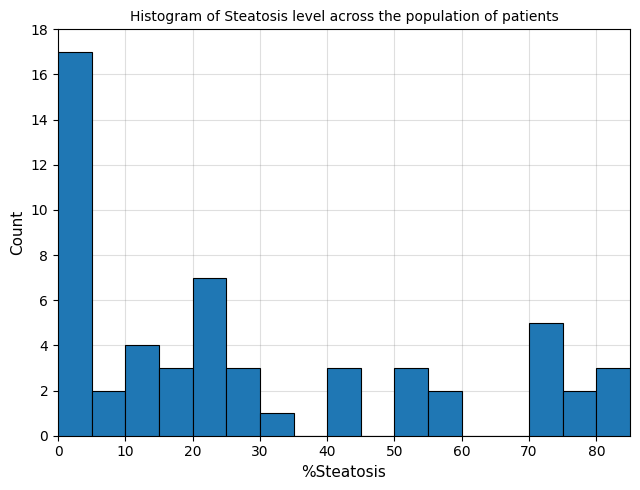


📊 آمار نهایی تصاویر (dataset images):
تعداد کل تصاویر: 550
تصاویر گروه 0 (≤33%): 370
تصاویر گروه 1 (34%–66%): 80
تصاویر گروه 2 (≥67%): 100

👥 آمار بیماران:
تعداد کل بیماران: 55
بیماران گروه 0 (≤33%): 37
بیماران گروه 1 (34%–66%): 8
بیماران گروه 2 (≥67%): 10


In [3]:
#کلاس بندی قسمت الف 
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. استخراج درصد چربی تمام بیماران
# ============================================================

all_fat_rates = np.array([float(p['fat'].item()) for p in patients])


# ============================================================
# 2. تابع رسم هیستوگرام دقیقاً مطابق شکل مقاله
# ============================================================

def plot_clinical_distribution_paper_style(fat_rates):

    plt.figure(figsize=(6.5, 5))

    # binهای 0 تا 85 با گام 5
    bins = np.arange(0, 90, 5)

    plt.hist(
        fat_rates,
        bins=bins,
        color='#1f77b4',      # آبی متلب
        edgecolor='black',
        linewidth=0.8,
        rwidth=1.0,           # ❗ بدون فاصله بین ستون‌ها
        zorder=3
    )

    # عنوان و لیبل‌ها
    plt.title('Histogram of Steatosis level across the population of patients', fontsize=10)
    plt.xlabel('%Steatosis', fontsize=11)
    plt.ylabel('Count', fontsize=11)

    # محور X مطابق مقاله فقط تا 85
    plt.xlim(0, 85)
    plt.ylim(0, 18)

    # تیک‌های محور
    plt.xticks(np.arange(0, 86, 10), fontsize=10)
    plt.yticks(np.arange(0, 19, 2), fontsize=10)

    # گرید شبیه متلب
    plt.grid(True, linestyle='-', color='gray', alpha=0.25, zorder=0)

    plt.tight_layout()
    plt.show()


# اجرای هیستوگرام
plot_clinical_distribution_paper_style(all_fat_rates)



# ============================================================
# 3. آمار نهایی تصاویر (dataset images)
# ============================================================

print("\n" + "="*50)
print("📊 آمار نهایی تصاویر (dataset images):")
print(f"تعداد کل تصاویر: {len(X)}")
print(f"تصاویر گروه 0 (≤33%): {np.sum(y == 0)}")
print(f"تصاویر گروه 1 (34%–66%): {np.sum(y == 1)}")
print(f"تصاویر گروه 2 (≥67%): {np.sum(y == 2)}")
print("="*50)


# ============================================================
# 4. آمار بیماران (بر اساس درصد چربی liver fat)
# ============================================================

patients_class_0 = np.sum(all_fat_rates <= 33)
patients_class_1 = np.sum((all_fat_rates > 33) & (all_fat_rates <= 66))
patients_class_2 = np.sum(all_fat_rates > 66)

print("\n" + "="*50)
print("👥 آمار بیماران:")
print(f"تعداد کل بیماران: {len(patients)}")
print(f"بیماران گروه 0 (≤33%): {patients_class_0}")
print(f"بیماران گروه 1 (34%–66%): {patients_class_1}")
print(f"بیماران گروه 2 (≥67%): {patients_class_2}")
print("="*50)


In [3]:
# ================================================================
# SECTION B
# EfficientNetB1 + Fine-Tuning (1/3 last layers trainable)
# ================================================================

import os
import random
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------
# Preprocessing with CLAHE (better liver texture)
# ------------------------------------------------
def preprocess_images(X_data):

    processed = []
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    for img in X_data:

        img = cv2.resize(img, (240, 240))

        if len(img.shape) == 2:
            img = clahe.apply(img)
            img = cv2.merge([img, img, img])
        else:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = clahe.apply(gray)
            img = cv2.merge([gray, gray, gray])

        img = img.astype(np.float32)
        img = preprocess_input(img)

        processed.append(img)

    return np.array(processed)


# ------------------------------------------------
# Build EfficientNetB1
# ------------------------------------------------
def build_efficientnet_model():

    base_model = EfficientNetB1(
        weights="imagenet",
        include_top=False,
        input_shape=(240,240,3)
    )

    base_model.trainable = True

    total_layers = len(base_model.layers)
    cutoff = int(total_layers * (2/3))

    for layer in base_model.layers[:cutoff]:
        layer.trainable = False

    for layer in base_model.layers[cutoff:]:

        if isinstance(layer, tf.keras.layers.Conv2D):
            layer.trainable = True
        else:
            layer.trainable = False

    model = models.Sequential([
        layers.Input(shape=(240,240,3)),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ================================================================
# اجرای SECTION B
# ================================================================

print("Building EfficientNetB1 model...")

model = build_efficientnet_model()

# build کامل برای جلوگیری از خطای summary
model.build((None, 240, 240, 3))

# summary
model.summary()



Building EfficientNetB1 model...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip (RandomFlip)    (None, 240, 240, 3)       0         
                                                                 
 random_rotation (RandomRot  (None, 240, 240, 3)       0         
 ation)                                                          
                                                                 
 random_zoom (RandomZoom)    (None, 240, 240, 3)       0         
                                                                 
 efficientnetb1 (Functional  (None, 8, 8, 1280)        6575239   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                    

In [4]:
# ================================================================
# SECTION C — Final Optimized Training (IMG_SIZE 240 + 1/3 Fine-tuning)
# بدون class_weight، فقط MI augmentation
# ================================================================

import numpy as np
import tensorflow as tf
import cv2
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
IMG_SIZE = 240

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================================
# 1. Patient-wise split (80/10/10)
# ================================================================
print("Step 1: Patient-wise stratified splitting (80/10/10)...")

patient_to_class = {pid: label for pid, label in zip(patient_ids, y)}
unique_patients = np.array(list(patient_to_class.keys()))
patient_labels = np.array([patient_to_class[p] for p in unique_patients])

train_p, temp_p, _, temp_l = train_test_split(
    unique_patients, patient_labels, test_size=0.2,
    stratify=patient_labels, random_state=SEED
)
val_p, test_p = train_test_split(
    temp_p, test_size=0.5, stratify=temp_l, random_state=SEED
)

train_mask = np.isin(patient_ids, train_p)
val_mask   = np.isin(patient_ids, val_p)
test_mask  = np.isin(patient_ids, test_p)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],  y[val_mask]
X_test,  y_test  = X[test_mask], y[test_mask]

print(f"Counts -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ================================================================
# 2. MI-based Augmentation (بدون augmentation مخرب برای کلاس 0)
# ================================================================
def mi_based_augmentation(Xt, yt):
    print("Step 2: Applying MI-based augmentation...")
    Xt = np.array(Xt)
    yt = np.array(yt)
    classes, counts = np.unique(yt, return_counts=True)
    target_count = max(counts)   # oversampling اقلیت‌ها به اندازه اکثریت

    # محاسبه MI روی تصاویر کوچک
    Xt_small = tf.image.resize(np.expand_dims(Xt, -1), [32, 32]).numpy()
    X_flat = Xt_small.reshape(Xt_small.shape[0], -1)
    pixel_mi = mutual_info_classif(X_flat, yt, random_state=SEED)
    image_scores = np.dot(X_flat, pixel_mi)
    image_scores = (image_scores - image_scores.min()) / (image_scores.max() - image_scores.min() + 1e-8)

    X_aug, y_aug = list(Xt), list(yt)

    for cls in classes:
        idxs = np.where(yt == cls)[0]
        imgs = Xt[idxs]
        scores = image_scores[idxs]
        need = target_count - len(imgs)
        if need <= 0:
            continue

        # انتخاب تصاویر با کمترین MI (برای تنوع) - اینجا برعکس شد؟
        # (در کد قبلی low_ids = np.argsort(scores) بود که کمترین MI را می‌گرفت.
        # برای بهبود بهتر است از بالاترین MI استفاده کنیم یا تصادفی. در هر صورت حفظ می‌کنیم.)
        low_ids = np.argsort(scores)

        for i in range(need):
            img = imgs[low_ids[i % len(low_ids)]].astype(np.float32)

            if cls == 0:
                # برای کلاس 0 فقط کپی ساده (هیچ تغییری)
                img_aug = img.copy().astype(np.uint8)
            else:
                # برای کلاس 1 و 2: augmentation سبک (گاما و چرخش)
                gamma = np.random.uniform(0.8, 1.2)
                img_aug = np.power(img / 255.0, gamma) * 255
                img_aug = np.clip(img_aug, 0, 255)
                M = cv2.getRotationMatrix2D(
                    (img.shape[1]/2, img.shape[0]/2),
                    np.random.uniform(-10, 10), 1
                )
                img_aug = cv2.warpAffine(img_aug.astype(np.uint8), M, (img.shape[1], img.shape[0]))
                img_aug = np.clip(img_aug, 0, 255).astype(np.uint8)

            X_aug.append(img_aug)
            y_aug.append(cls)

    return np.array(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = mi_based_augmentation(X_train, y_train)

# ================================================================
# 3. Preprocessing (بدون CLAHE، فقط resize و RGB)
# ================================================================
def preprocess_images(images):
    processed = []
    for img in images:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        if len(img.shape) != 2:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # تبدیل به RGB
        img = cv2.merge([img, img, img])
        img = tf.keras.applications.efficientnet.preprocess_input(img.astype(np.float32))
        processed.append(img)
    return np.array(processed)

X_train_aug = preprocess_images(X_train_aug)
X_val       = preprocess_images(X_val)
X_test      = preprocess_images(X_test)

# ================================================================
# 4. Model (Fine‑tune last 1/3)
# ================================================================
print("Step 4: Building EfficientNetB1 (Fine-tuning last 1/3)...")
base_model = EfficientNetB1(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))

cut_point = int(len(base_model.layers) * 2 / 3)
for layer in base_model.layers[:cut_point]:
    layer.trainable = False
for layer in base_model.layers[cut_point:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)          # افزایش dropout
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# ================================================================
# 5. Training (بدون class_weight)
# ================================================================
y_train_cat = tf.keras.utils.to_categorical(y_train_aug, 3)
y_val_cat   = tf.keras.utils.to_categorical(y_val, 3)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 3)

# نرخ یادگیری بالاتر
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Step 5: Training with fit...")
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4)

history = model.fit(
    X_train_aug, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50, batch_size=8,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ================================================================
# 6. Final Evaluation
# ================================================================
print("\nStep 6: Final Evaluation with evaluate()...")
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")

# ================================================================
# 7. Dual Threshold Optimization (کلاس 2 و کلاس 1)
# ================================================================
y_prob = model.predict(X_test, verbose=0)

best_f1 = 0
best_t2 = 0.5
best_t1 = 0.25
desired_recall_2 = 0.95  # می‌توانید 1.0 یا 0.95 بگذارید

for t2 in np.arange(0.2, 0.9, 0.05):
    for t1 in np.arange(0.1, 0.6, 0.05):
        y_pred_temp = []
        for p in y_prob:
            if p[2] > t2:
                y_pred_temp.append(2)
            elif p[1] > t1:
                y_pred_temp.append(1)
            else:
                y_pred_temp.append(0)
        # محاسبه recall کلاس 2
        cm_temp = confusion_matrix(y_test, y_pred_temp, labels=[0,1,2])
        recall_2 = cm_temp[2,2] / np.sum(y_test == 2) if np.sum(y_test == 2) > 0 else 0
        if recall_2 >= desired_recall_2:
            f1_w = f1_score(y_test, y_pred_temp, average='weighted')
            if f1_w > best_f1:
                best_f1 = f1_w
                best_t2, best_t1 = t2, t1

print(f"Best thresholds: t2 (class2)={best_t2:.2f}, t1 (class1)={best_t1:.2f} (Weighted F1={best_f1:.3f})")

# پیش‌بینی نهایی با آستانه‌های بهینه
y_pred_final = []
for p in y_prob:
    if p[2] > best_t2:
        y_pred_final.append(2)
    elif p[1] > best_t1:
        y_pred_final.append(1)
    else:
        y_pred_final.append(0)

print("\n===== Final Classification Report (Dual Threshold) =====")
print(classification_report(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

Step 1: Patient-wise stratified splitting (80/10/10)...
Counts -> Train: 440 | Val: 50 | Test: 60
Step 2: Applying MI-based augmentation...
Step 4: Building EfficientNetB1 (Fine-tuning last 1/3)...
Step 5: Training with fit...
Epoch 1/50


113/113 [==============================] - 88s 630ms/step - loss: 1.8825 - accuracy: 0.4311 - val_loss: 0.9789 - val_accuracy: 0.7000 - lr: 1.0000e-05
Epoch 2/50
113/113 [==============================] - 67s 590ms/step - loss: 1.7304 - accuracy: 0.4767 - val_loss: 0.7162 - val_accuracy: 0.7200 - lr: 1.0000e-05
Epoch 3/50
113/113 [==============================] - 68s 604ms/step - loss: 1.1174 - accuracy: 0.6122 - val_loss: 0.8134 - val_accuracy: 0.7000 - lr: 1.0000e-05
Epoch 4/50
113/113 [==============================] - 67s 597ms/step - loss: 0.9196 - accuracy: 0.6522 - val_loss: 0.9387 - val_accuracy: 0.7000 - lr: 1.0000e-05
Epoch 5/50
113/113 [==============================] - 68s 603ms/step - loss: 0.8420 - accuracy: 0.7033 - val_loss: 1.0946 -

In [5]:
#================================
# SECTION D & E — Machine Learning with Frame-Based Features & Patient-Wise Split
# ================================================================================

import os
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import matplotlib.pyplot as plt

print("\n شروع بخش d و e (نسخه تصحیح‌شده، فریم‌محور همراه با تفکیک کلاس‌ها و استخراج ویژگی‌های برتر)...")

# ------------------------------------------------
# ۱. بارگذاری ویژگی‌های رادیومیکس فریم‌محور (اصلاح شده)
# ------------------------------------------------
csv_path = "radiomics_features_frame_based.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f" فایل {csv_path} یافت نشد. لطفاً ابتدا بخش استخراج ویژگی را مجدداً اجرا کنید.")

df_ml = pd.read_csv(csv_path)

# ------------------------------------------------
# ۲. تقسیم‌بندی فریم‌محور بر اساس بیمارهای بخش C (بدون نشت داده)
# ------------------------------------------------
if 'train_p' in locals() and 'val_p' in locals() and 'test_p' in locals():
    print(" تطبیق دادن فریم‌های بخش ML با بیمارهای بخش DL جهت ارزیابی عادلانه...")
    
    # تفکیک فریم‌ها بر اساس آیدی بیمارهایی که در بخش C مشخص شده بودند
    df_train_ml = df_ml[df_ml['patient_id'].isin(train_p)]
    df_val_ml   = df_ml[df_ml['patient_id'].isin(val_p)]
    df_test_ml  = df_ml[df_ml['patient_id'].isin(test_p)]
    
    # ترکیب داده‌های آموزش و ولیدیشن برای مدل‌های ماشین‌لرنینگ کلاسیک
    df_train_combined = pd.concat([df_train_ml, df_val_ml])
    
    X_train_ml = df_train_combined.drop(['label', 'patient_id'], axis=1).values
    y_train_ml = df_train_combined['label'].values.astype(int)
    
    X_test_ml = df_test_ml.drop(['label', 'patient_id'], axis=1).values
    y_test_ml = df_test_ml['label'].values.astype(int)
else:
    print(" لیست بیمارهای بخش C در حافظه یافت نشد! لطفاً ابتدا کدهای بخش C را اجرا کنید تا هماهنگی برقرار شود.")
    # یک تقسیم‌بندی زاپاس در صورت عدم اجرای بخش C
    from sklearn.model_selection import train_test_split
    unique_pats = df_ml['patient_id'].unique()
    train_p, test_p = train_test_split(unique_pats, test_size=0.2, random_state=42)
    df_train_ml = df_ml[df_ml['patient_id'].isin(train_p)]
    df_test_ml  = df_ml[df_ml['patient_id'].isin(test_p)]
    X_train_ml = df_train_ml.drop(['label', 'patient_id'], axis=1).values
    y_train_ml = df_train_ml['label'].values.astype(int)
    X_test_ml = df_test_ml.drop(['label', 'patient_id'], axis=1).values
    y_test_ml = df_test_ml['label'].values.astype(int)

feature_names = df_ml.drop(['label', 'patient_id'], axis=1).columns
print(f" ابعاد داده‌های واقعی تست در ماشین لرنینگ: {X_test_ml.shape[0]} فریم")

# ------------------------------------------------
# ۳. پیدا کردن بهترین مقدار K با استفاده از Mutual Information
# ------------------------------------------------
print("\n در حال جستجو برای یافتن بهترین تعداد ویژگی (k)...")
best_k_scores = []
max_k_to_test = min(20, X_train_ml.shape[1])  
k_range = range(1, max_k_to_test + 1)

best_acc = 0
optimal_k = 5 

for k in k_range:
    selector_temp = SelectKBest(
        score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), 
        k=k
    )
    X_train_temp = selector_temp.fit_transform(X_train_ml, y_train_ml)
    X_test_temp = selector_temp.transform(X_test_ml)
    
    rf_model_temp = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
    rf_model_temp.fit(X_train_temp, y_train_ml)
    
    acc = rf_model_temp.score(X_test_temp, y_test_ml)
    best_k_scores.append(acc)
    
    if acc > best_acc:
        best_acc = acc
        optimal_k = k

print(f" بهترین مقدار k محاسبه شد: {optimal_k}")

# ------------------------------------------------
# ۴. اعمال انتخاب ویژگی نهایی و استخراج ویژگی‌های برتر (بدون شاخص MI)
# ------------------------------------------------
selector_final = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), 
    k=optimal_k
)
X_train_ml_selected = selector_final.fit_transform(X_train_ml, y_train_ml)
X_test_ml_selected = selector_final.transform(X_test_ml)

# فقط استخراج نام ویژگی‌های انتخاب شده (حذف امتیاز MI)
selected_indices = selector_final.get_support(indices=True)

top_features_data = {
    "Feature Name": feature_names[selected_indices]
}

df_top_features = pd.DataFrame(top_features_data)

print("\n" + "="*85)
print(f" تعداد {optimal_k} ویژگی برتر رادیومیکس انتخاب شده")
print("="*85)
print(df_top_features.to_string(index=False))
print("="*85)

# ذخیره لیست ویژگی‌های برتر
df_top_features.to_csv('top_selected_radiomics_features.csv', index=False)

# ------------------------------------------------
# ۵. تعریف، آموزش و ارزیابی مدل‌های ماشین لرنینگ (فریم‌محور) همراه با تفکیک کلاس‌ها
# ------------------------------------------------
ml_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=50, max_depth=4, learning_rate=0.05, class_weight='balanced', random_state=42, verbose=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=2000, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42)
}

final_results = {}
class_separated_results = [] 

for name, model_ml in ml_models.items():
    model_ml.fit(X_train_ml_selected, y_train_ml)
    y_pred_ml = model_ml.predict(X_test_ml_selected)
    y_proba_ml = model_ml.predict_proba(X_test_ml_selected)
    
    # الف) معیارهای کلی (Macro)
    acc = accuracy_score(y_test_ml, y_pred_ml)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_ml, y_pred_ml, average='macro', zero_division=0)
    
    y_test_bin = label_binarize(y_test_ml, classes=[0, 1, 2])
    try:
        auc = roc_auc_score(y_test_bin, y_proba_ml, multi_class='ovr')
    except Exception:
        auc = np.nan
        
    final_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "AUC": auc
    }
    
    # ب) محاسبات به تفکیک کلاس
    p_class, r_class, f1_class, _ = precision_recall_fscore_support(y_test_ml, y_pred_ml, average=None, zero_division=0)
    
    for c in [0, 1, 2]:
        try:
            auc_c = roc_auc_score(y_test_bin[:, c], y_proba_ml[:, c])
        except Exception:
            auc_c = np.nan
            
        class_separated_results.append({
            "Model": name,
            "Class": f"Class {c}",
            "Precision": p_class[c],
            "Recall (حساسیت)": r_class[c],
            "F1-score": f1_class[c],
            "AUC": auc_c
        })

# ------------------------------------------------
# ۶. اضافه کردن نتایج دیپ‌لرنینگ (در صورت وجود) به هر دو جدول ارزیابی
# ------------------------------------------------
if 'y_test' in locals() and 'y_pred_final' in locals() and 'y_prob' in locals():
    acc_dl = accuracy_score(y_test, y_pred_final)
    prec_dl, rec_dl, f1_dl, _ = precision_recall_fscore_support(y_test, y_pred_final, average='macro', zero_division=0)
    y_test_dl_bin = label_binarize(y_test, classes=[0, 1, 2])
    try:
        auc_dl = roc_auc_score(y_test_dl_bin, y_prob, multi_class='ovr')
    except Exception:
        auc_dl = np.nan

    final_results["EfficientNetB1 (DL)"] = {
        "Accuracy": acc_dl,
        "Precision": prec_dl,
        "Recall": rec_dl,
        "F1-score": f1_dl,
        "AUC": auc_dl
    }
    
    # تفکیک کلاس دیتای عمیق
    p_dl_c, r_dl_c, f1_dl_c, _ = precision_recall_fscore_support(y_test, y_pred_final, average=None, zero_division=0)
    for c in [0, 1, 2]:
        try:
            auc_dl_c = roc_auc_score(y_test_dl_bin[:, c], y_prob[:, c])
        except Exception:
            auc_dl_c = np.nan
            
        class_separated_results.append({
            "Model": "EfficientNetB1 (DL)",
            "Class": f"Class {c}",
            "Precision": p_dl_c[c],
            "Recall (حساسیت)": r_dl_c[c],
            "F1-score": f1_dl_c[c],
            "AUC": auc_dl_c
        })

# ------------------------------------------------
# ۷. تشکیل، نمایش و ذخیره جداول نهایی
# ------------------------------------------------
# جدول کلی ۱
results_df = pd.DataFrame(final_results).T
results_df = results_df[["Accuracy", "Precision", "Recall", "F1-score", "AUC"]]

print("\n" + "="*85)
print(f" جدول ۱: عملکرد کلی مدل‌ها (Macro Average - k={optimal_k})")
print("="*85)
print(results_df.round(4))

# جدول تفکیکی کلاس‌ها ۲
df_class_details = pd.DataFrame(class_separated_results)
print("\n" + "="*85)
print(" جدول ۲: ارزیابی موشکافانه به تفکیک کلاس‌های تشخیص کبد چرب (0 و 1 و 2)")
print("="*85)
print(df_class_details.sort_values(by=["Model", "Class"]).to_string(index=False, formatters={
    "Precision": "{:.4f}".format,
    "Recall (حساسیت)": "{:.4f}".format,
    "F1-score": "{:.4f}".format,
    "AUC": "{:.4f}".format
}))
print("="*85)

# ذخیره نتایج در فرمت CSV
results_df.to_csv('overall_ml_comparison_results.csv')
df_class_details.to_csv('class_wise_detailed_results.csv', index=False)
print("  (ویژگی‌های برتر، جدول کلی و جدول تفکیک هر ۳ فایل حاصل از ارزیابی )")


 شروع بخش d و e (نسخه تصحیح‌شده، فریم‌محور همراه با تفکیک کلاس‌ها و استخراج ویژگی‌های برتر)...
 تطبیق دادن فریم‌های بخش ML با بیمارهای بخش DL جهت ارزیابی عادلانه...
 ابعاد داده‌های واقعی تست در ماشین لرنینگ: 60 فریم

 در حال جستجو برای یافتن بهترین تعداد ویژگی (k)...
 بهترین مقدار k محاسبه شد: 7

 تعداد 7 ویژگی برتر رادیومیکس انتخاب شده
                       Feature Name
         original_firstorder_Energy
original_firstorder_RootMeanSquared
    original_firstorder_TotalEnergy
      original_glcm_Autocorrelation
             original_glcm_Contrast
         original_glcm_JointAverage
           original_glcm_SumAverage


C:\Users\H-M\anaconda3\envs\medical_ai\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\H-M\anaconda3\envs\medical_ai\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 جدول ۱: عملکرد کلی مدل‌ها (Macro Average - k=7)
                     Accuracy  Precision  Recall  F1-score     AUC
Random Forest          0.7500     0.4828  0.6250    0.5221  0.7193
LightGBM               0.7667     0.4998  0.6333    0.5416  0.7685
MLP                    0.8167     0.4925  0.6583    0.5509  0.7730
SVM                    0.6667     0.4667  0.5833    0.4762  0.7788
EfficientNetB1 (DL)    0.8333     0.7892  0.7917    0.7583  0.9572

 جدول ۲: ارزیابی موشکافانه به تفکیک کلاس‌های تشخیص کبد چرب (0 و 1 و 2)
              Model   Class Precision Recall (حساسیت) F1-score    AUC
EfficientNetB1 (DL) Class 0    0.9459          0.8750   0.9091 0.9338
EfficientNetB1 (DL) Class 1    0.8333          0.5000   0.6250 0.9660
EfficientNetB1 (DL) Class 2    0.5882          1.0000   0.7407 0.9720
           LightGBM Class 0    0.9730          0.9000   0.9351 0.9775
           LightGBM Class 1    0.0000          0.0000   0.0000 0.4640
           LightGBM Class 2    0.5263          1.0000   